In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF/03.shortRNA_filtering")
QC = ROOT / "qc"
OUT = QC / "plots_filtering"
OUT.mkdir(parents=True, exist_ok=True)

counts = pd.read_csv(QC / "filter_counts.tsv", sep="\t")
counts.head(), counts.columns

(    sample                stage     reads
 0  CD14_S1                input  11276318
 1  CD14_S1         tRNA_matched     71486
 2  CD14_S1             not_tRNA  11204832
 3  CD14_S1   RNAcentral_matched     16404
 4  CD14_S1  candidate_remaining  11188428,
 Index(['sample', 'stage', 'reads'], dtype='object'))

In [2]:
# Inspect actual column names
print(counts.columns.tolist())
display(counts.head())

['sample', 'stage', 'reads']


,sample,stage,reads
0,CD14_S1,input,11276318
1,CD14_S1,tRNA_matched,71486
2,CD14_S1,not_tRNA,11204832
3,CD14_S1,RNAcentral_matched,16404
4,CD14_S1,candidate_remaining,11188428


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF/03.shortRNA_filtering")
QC = ROOT / "qc"
OUT = QC / "plots_filtering"
OUT.mkdir(parents=True, exist_ok=True)

counts_long = pd.read_csv(QC / "filter_counts.tsv", sep="\t")

stage_order = [
    "input",
    "not_tRNA",
    "candidate_remaining"
]

retention = counts_long[counts_long["stage"].isin(stage_order)].copy()

retention["stage"] = pd.Categorical(
    retention["stage"],
    categories=stage_order,
    ordered=True
)

retention["cell_type"] = retention["sample"].str.replace(r"_S\\d+$", "", regex=True)

retention.head()

,sample,stage,reads,cell_type
0,CD14_S1,input,11276318,CD14_S1
2,CD14_S1,not_tRNA,11204832,CD14_S1
4,CD14_S1,candidate_remaining,11188428,CD14_S1
5,CD14_S2,input,13203188,CD14_S2
7,CD14_S2,not_tRNA,13160577,CD14_S2


### full stack filtering


In [5]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
NFCORE = ROOT / "01.nfcore_smrnaseq"
CUSTOM = ROOT / "03.shortRNA_filtering"

OUT = CUSTOM / "qc" / "full_filtering_plots"
OUT.mkdir(parents=True, exist_ok=True)

In [6]:
fastp_rows = []

for fp in sorted((NFCORE / "fastp" / "on_raw").glob("*.fastp.json")):
    sample = fp.name.replace(".fastp.json", "")
    
    with open(fp) as f:
        js = json.load(f)
    
    fastp_rows.append({
        "sample": sample,
        "raw_reads": js["summary"]["before_filtering"]["total_reads"],
        "passed_fastp": js["summary"]["after_filtering"]["total_reads"],
        "failed_fastp": js["summary"]["before_filtering"]["total_reads"] - js["summary"]["after_filtering"]["total_reads"],
    })

fastp_df = pd.DataFrame(fastp_rows)
fastp_df.head()

,sample,raw_reads,passed_fastp,failed_fastp
0,CD14_S1,33666454,33506607,159847
1,CD14_S2,36356801,36214299,142502
2,CD14_S3,35451156,35314440,136716
3,CD14_S4,37654239,36851285,802954
4,CD19_S1,30739877,30530036,209841


## parse mature/hairpin miRNA counts

In [7]:
mature_counts = pd.read_csv(NFCORE / "mirna_quant" / "edger_qc" / "mature_counts.csv", index_col=0)
hairpin_counts = pd.read_csv(NFCORE / "mirna_quant" / "edger_qc" / "hairpin_counts.csv", index_col=0)

mature_mapped = mature_counts.sum(axis=0).reset_index()
mature_mapped.columns = ["sample", "mature_miRNA_mapped"]

hairpin_mapped = hairpin_counts.sum(axis=0).reset_index()
hairpin_mapped.columns = ["sample", "hairpin_miRNA_mapped"]

mature_mapped.head(), hairpin_mapped.head()

(            sample  mature_miRNA_mapped
 0    hsa-let-7a-5p              9735596
 1    hsa-let-7a-3p                14464
 2  hsa-let-7a-2-3p                 2464
 3    hsa-let-7b-5p              1925111
 4    hsa-let-7b-3p                 3189,
          sample  hairpin_miRNA_mapped
 0  hsa-let-7a-1                 86132
 1  hsa-let-7a-2                 82646
 2  hsa-let-7a-3                 86694
 3    hsa-let-7b                 97146
 4    hsa-let-7c                  3886)

## parse custom tRNA/RNAcentral filtering

In [8]:
custom_long = pd.read_csv(CUSTOM / "qc" / "filter_counts.tsv", sep="\t")

custom_wide = (
    custom_long
    .pivot_table(index="sample", columns="stage", values="reads", aggfunc="sum")
    .reset_index()
)

custom_wide.head()

stage,sample,RNAcentral_matched,candidate_remaining,input,not_tRNA,tRNA_matched
0,CD14_S1,16404,11188428,11276318,11204832,71486
1,CD14_S2,10453,13150124,13203188,13160577,42611
2,CD14_S3,9585,11503049,11535091,11512634,22457
3,CD14_S4,11170,17532591,17559159,17543761,15398
4,CD19_S1,10108,19169765,19191518,19179873,11645


In [9]:
custom_wide = custom_wide.rename(columns={
    "input": "mature_hairpin_unmapped",
    "candidate_remaining": "candidate_shortRNA"
})

custom_wide.head()

stage,sample,RNAcentral_matched,candidate_shortRNA,mature_hairpin_unmapped,not_tRNA,tRNA_matched
0,CD14_S1,16404,11188428,11276318,11204832,71486
1,CD14_S2,10453,13150124,13203188,13160577,42611
2,CD14_S3,9585,11503049,11535091,11512634,22457
3,CD14_S4,11170,17532591,17559159,17543761,15398
4,CD19_S1,10108,19169765,19191518,19179873,11645


In [10]:
full = (
    fastp_df
    .merge(mature_mapped, on="sample", how="outer")
    .merge(hairpin_mapped, on="sample", how="outer")
    .merge(custom_wide, on="sample", how="outer")
)

full["cell_type"] = full["sample"].str.replace(r"_S\d+$", "", regex=True)
full["replicate"] = full["sample"].str.extract(r"_S(\d+)$")

full = full.sort_values(["cell_type", "replicate"])

full

,sample,raw_reads,passed_fastp,failed_fastp,mature_miRNA_mapped,hairpin_miRNA_mapped,RNAcentral_matched,candidate_shortRNA,mature_hairpin_unmapped,not_tRNA,tRNA_matched,cell_type,replicate
0,CD14_S1,33666454.0,33506607.0,159847.0,NaN,NaN,16404.0,11188428.0,11276318.0,11204832.0,71486.0,CD14,1
1,CD14_S2,36356801.0,36214299.0,142502.0,NaN,NaN,10453.0,13150124.0,13203188.0,13160577.0,42611.0,CD14,2
2,CD14_S3,35451156.0,35314440.0,136716.0,NaN,NaN,9585.0,11503049.0,11535091.0,11512634.0,22457.0,CD14,3
3,CD14_S4,37654239.0,36851285.0,802954.0,NaN,NaN,11170.0,17532591.0,17559159.0,17543761.0,15398.0,CD14,4
4,CD19_S1,30739877.0,30530036.0,209841.0,NaN,NaN,10108.0,19169765.0,19191518.0,19179873.0,11645.0,CD19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4584,hsa-mir-9983,NaN,NaN,NaN,NaN,314.0,NaN,NaN,NaN,NaN,NaN,hsa-mir-9983,NaN
4585,hsa-mir-9985,NaN,NaN,NaN,NaN,1046.0,NaN,NaN,NaN,NaN,NaN,hsa-mir-9985,NaN
4586,hsa-mir-9986,NaN,NaN,NaN,NaN,840.0,NaN,NaN,NaN,NaN,NaN,hsa-mir-9986,NaN
4587,hsa-mir-99a,NaN,NaN,NaN,NaN,1028.0,NaN,NaN,NaN,NaN,NaN,hsa-mir-99a,NaN


In [11]:
full_out = CUSTOM / "qc" / "full_filtering_counts.tsv"
full.to_csv(full_out, sep="\t", index=False)

full_out

PosixPath('/samurlab1/Joshua/smallRNA_USRF/03.shortRNA_filtering/qc/full_filtering_counts.tsv')

In [12]:
stage_order = [
    "raw_reads",
    "passed_fastp",
    "mature_hairpin_unmapped",
    "not_tRNA",
    "candidate_shortRNA",
]

plot_long = full.melt(
    id_vars=["sample", "cell_type", "replicate"],
    value_vars=[c for c in stage_order if c in full.columns],
    var_name="stage",
    value_name="reads_remaining"
)

plot_long["stage"] = pd.Categorical(plot_long["stage"], categories=stage_order, ordered=True)
plot_long = plot_long.dropna()

plot_long.head()

,sample,cell_type,replicate,stage,reads_remaining
0,CD14_S1,CD14,1,raw_reads,33666454.0
1,CD14_S2,CD14,2,raw_reads,36356801.0
2,CD14_S3,CD14,3,raw_reads,35451156.0
3,CD14_S4,CD14,4,raw_reads,37654239.0
4,CD19_S1,CD19,1,raw_reads,30739877.0


In [13]:
stage_order = [
    "raw_reads",
    "passed_fastp",
    "mature_hairpin_unmapped",
    "not_tRNA",
    "candidate_shortRNA",
]

plot_long = full.melt(
    id_vars=["sample", "cell_type", "replicate"],
    value_vars=[c for c in stage_order if c in full.columns],
    var_name="stage",
    value_name="reads_remaining"
)

plot_long["stage"] = pd.Categorical(plot_long["stage"], categories=stage_order, ordered=True)
plot_long = plot_long.dropna()

plot_long.head()

,sample,cell_type,replicate,stage,reads_remaining
0,CD14_S1,CD14,1,raw_reads,33666454.0
1,CD14_S2,CD14,2,raw_reads,36356801.0
2,CD14_S3,CD14,3,raw_reads,35451156.0
3,CD14_S4,CD14,4,raw_reads,37654239.0
4,CD19_S1,CD19,1,raw_reads,30739877.0


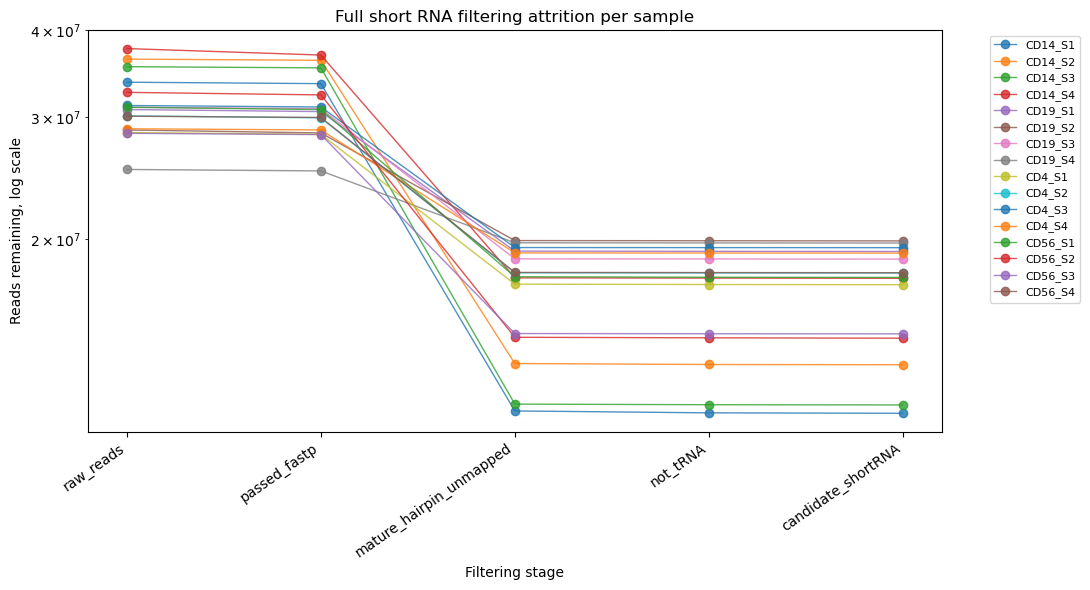

In [15]:
plt.figure(figsize=(11, 6))

for sample, sub in plot_long.groupby("sample"):
    sub = sub.sort_values("stage")
    plt.plot(
        sub["stage"].astype(str),
        sub["reads_remaining"],
        marker="o",
        linewidth=1,
        alpha=0.8,
        label=sample
    )

plt.yscale("log")
plt.xlabel("Filtering stage")
plt.ylabel("Reads remaining, log scale")
plt.title("Full short RNA filtering attrition per sample")
plt.xticks(rotation=35, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()

plt.savefig(OUT / "full_filtering_reads_remaining_per_sample_log.png", dpi=300)
plt.show()

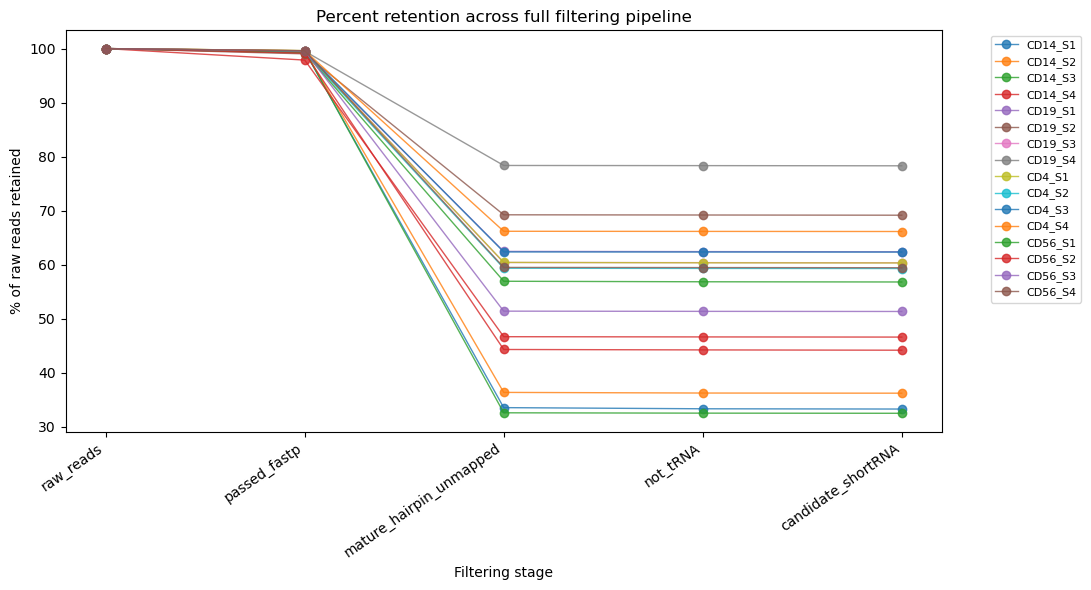

In [16]:
plot_pct = plot_long.merge(
    full[["sample", "raw_reads"]],
    on="sample",
    how="left"
)

plot_pct["percent_of_raw"] = plot_pct["reads_remaining"] / plot_pct["raw_reads"] * 100

plt.figure(figsize=(11, 6))

for sample, sub in plot_pct.groupby("sample"):
    sub = sub.sort_values("stage")
    plt.plot(
        sub["stage"].astype(str),
        sub["percent_of_raw"],
        marker="o",
        linewidth=1,
        alpha=0.8,
        label=sample
    )

plt.xlabel("Filtering stage")
plt.ylabel("% of raw reads retained")
plt.title("Percent retention across full filtering pipeline")
plt.xticks(rotation=35, ha="right")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()

plt.savefig(OUT / "full_filtering_percent_retained_per_sample.png", dpi=300)
plt.show()

In [17]:
import gzip
from pathlib import Path
import pandas as pd

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
CUSTOM = ROOT / "03.shortRNA_filtering"
OUT_QC = CUSTOM / "qc"

def count_fastq_lengths(path, min_len=10, max_len=20):
    total = 0
    in_window = 0
    
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(f):
            if i % 4 == 1:
                seq_len = len(line.strip())
                total += 1
                if min_len <= seq_len <= max_len:
                    in_window += 1
                    
    return total, in_window

records = []

for sample_dir in sorted((CUSTOM / "03.filtered").glob("*")):
    if not sample_dir.is_dir():
        continue
    
    sample = sample_dir.name
    
    files = {
        "not_tRNA": sample_dir / f"{sample}.not_tRNA.fastq.gz",
        "candidate_USRF": sample_dir / f"{sample}.candidate_shortRNA.fastq.gz",
        "tRNA_matched": sample_dir / f"{sample}.tRNA_matched.fastq.gz",
        "RNAcentral_matched": sample_dir / f"{sample}.RNAcentral_matched.fastq.gz",
    }
    
    for stage, fq in files.items():
        if fq.exists():
            total, n_10_20 = count_fastq_lengths(fq, 10, 20)
            records.append({
                "sample": sample,
                "stage": stage,
                "total_reads": total,
                "reads_10_20nt": n_10_20,
                "percent_10_20nt": n_10_20 / total * 100 if total else 0
            })


In [19]:

usrf_len_counts = pd.DataFrame(records)
usrf_len_counts.to_csv(OUT_QC / "usrf_10_20nt_filter_counts.tsv", sep="\t", index=False)

usrf_len_counts.head()

,sample,stage,total_reads,reads_10_20nt,percent_10_20nt
0,CD14_S1,not_tRNA,11204832,1284496,11.463768
1,CD14_S1,candidate_USRF,11188428,1273082,11.378560
2,CD14_S1,tRNA_matched,71486,14284,19.981535
3,CD14_S1,RNAcentral_matched,16404,11414,69.580590
4,CD14_S2,not_tRNA,13160577,1084234,8.238499


In [20]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"
OUT = QC / "usrf_10_20nt_plots"
OUT.mkdir(parents=True, exist_ok=True)

# if your dataframe is named usrf_len_counts
usrf_len_counts.to_csv(QC / "usrf_10_20nt_filter_counts.tsv", sep="\t", index=False)

In [24]:
df = pd.read_csv(QC / "usrf_10_20nt_filter_counts.tsv", sep="\t")

print(df.shape)
print(df.columns.tolist())
display(df.head())

(64, 5)
['sample', 'stage', 'total_reads', 'reads_10_20nt', 'percent_10_20nt']


,sample,stage,total_reads,reads_10_20nt,percent_10_20nt
0,CD14_S1,not_tRNA,11204832,1284496,11.463768
1,CD14_S1,candidate_USRF,11188428,1273082,11.378560
2,CD14_S1,tRNA_matched,71486,14284,19.981535
3,CD14_S1,RNAcentral_matched,16404,11414,69.580590
4,CD14_S2,not_tRNA,13160577,1084234,8.238499


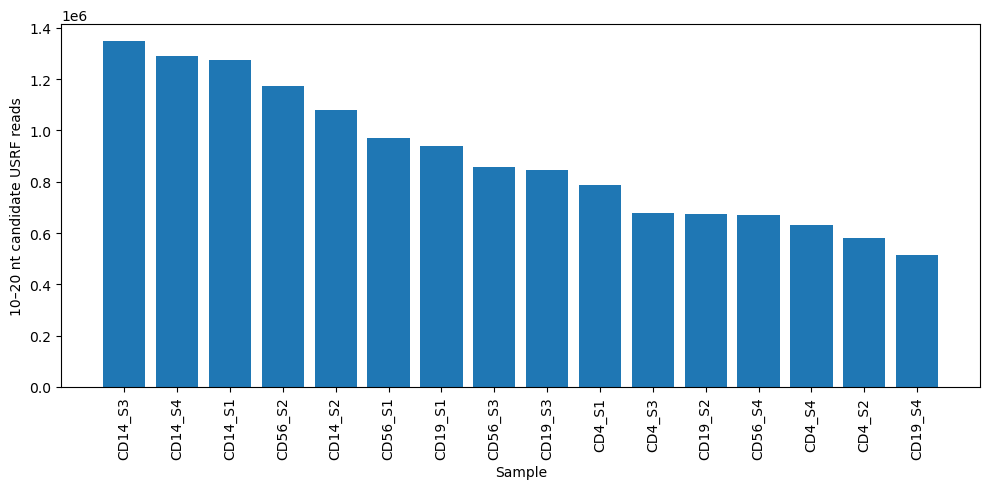

In [26]:
plot_df = df[df["stage"] == "candidate_USRF"].copy()

plot_df = plot_df.sort_values("reads_10_20nt", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(plot_df["sample"], plot_df["reads_10_20nt"])
plt.ylabel("10–20 nt candidate USRF reads")
plt.xlabel("Sample")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

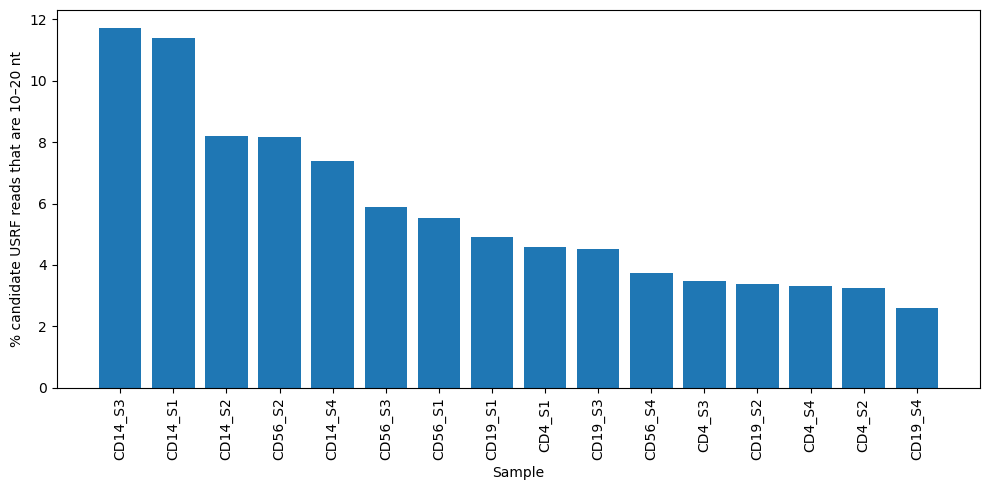

In [27]:
plot_df = df[df["stage"] == "candidate_USRF"].copy()
plot_df = plot_df.sort_values("percent_10_20nt", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(plot_df["sample"], plot_df["percent_10_20nt"])
plt.ylabel("% candidate USRF reads that are 10–20 nt")
plt.xlabel("Sample")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

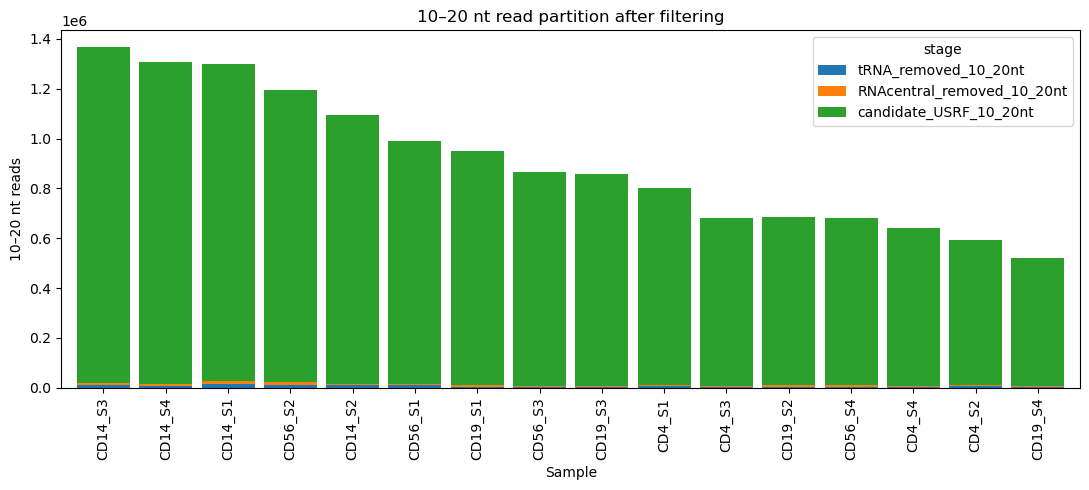

In [29]:
wide = (
    df.pivot_table(
        index="sample",
        columns="stage",
        values="reads_10_20nt",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

wide["tRNA_removed_10_20nt"] = wide.get("tRNA_matched", 0)
wide["RNAcentral_removed_10_20nt"] = wide.get("RNAcentral_matched", 0)
wide["candidate_USRF_10_20nt"] = wide.get("candidate_USRF", 0)

plot_df = wide.copy()

stack_cols = [
    "tRNA_removed_10_20nt",
    "RNAcentral_removed_10_20nt",
    "candidate_USRF_10_20nt",
]

plot_df = plot_df.sort_values("candidate_USRF_10_20nt", ascending=False)

ax = plot_df.set_index("sample")[stack_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(11,5),
    width=0.85
)

ax.set_ylabel("10–20 nt reads")
ax.set_xlabel("Sample")
ax.set_title("10–20 nt read partition after filtering")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

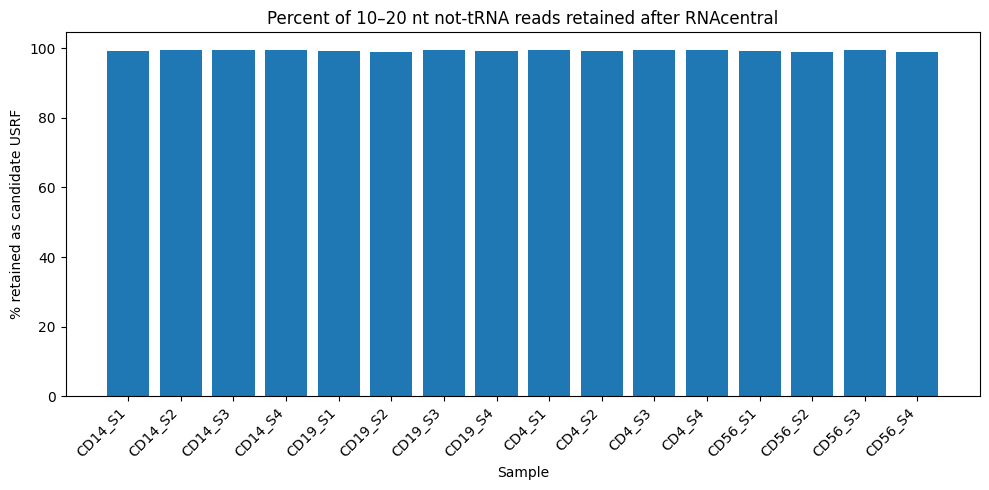

In [7]:
plot_df["pct_candidate_of_not_tRNA_10_20nt"] = (
    plot_df["candidate_USRF"] / plot_df["not_tRNA"] * 100
)

plt.figure(figsize=(10,5))
plt.bar(plot_df["sample"], plot_df["pct_candidate_of_not_tRNA_10_20nt"])
plt.ylabel("% retained as candidate USRF")
plt.xlabel("Sample")
plt.title("Percent of 10–20 nt not-tRNA reads retained after RNAcentral")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "pct_10_20nt_retained_after_RNAcentral.png", dpi=300)
plt.show()

In [32]:
print(plot_full_usrf.columns.tolist())
print(plot_df.columns.tolist())

['sample', 'RNAcentral_matched', 'candidate_USRF', 'not_tRNA', 'tRNA_matched', 'tRNA_removed_11_20nt', 'RNAcentral_removed_11_20nt', 'candidate_USRF_11_20nt', 'mature_miRNA_mapped_total', 'hairpin_miRNA_mapped_total']
['sample', 'RNAcentral_matched', 'candidate_USRF', 'not_tRNA', 'tRNA_matched', 'tRNA_removed_11_20nt', 'RNAcentral_removed_11_20nt', 'candidate_USRF_11_20nt']


In [34]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
NFCORE = ROOT / "01.nfcore_smrnaseq"
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"
OUT = QC / "usrf_11_20nt_plots"
OUT.mkdir(parents=True, exist_ok=True)

# reload your 11–20 nt table
usrf_len_counts = pd.read_csv(QC / "usrf_11_20nt_filter_counts.tsv", sep="\t")

plot_df = (
    usrf_len_counts
    .pivot(index="sample", columns="stage", values="reads_11_20nt")
    .reset_index()
)

plot_df["tRNA_removed_11_20nt"] = plot_df["tRNA_matched"]
plot_df["RNAcentral_removed_11_20nt"] = plot_df["RNAcentral_matched"]
plot_df["candidate_USRF_11_20nt"] = plot_df["candidate_USRF"]

# load upstream miRNA/hairpin totals
mature_counts = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "mature_counts.csv",
    index_col=0
)

hairpin_counts = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "hairpin_counts.csv",
    index_col=0
)

mature_mapped = mature_counts.sum(axis=0).reset_index()
mature_mapped.columns = ["sample", "mature_miRNA_mapped_total"]

hairpin_mapped = hairpin_counts.sum(axis=0).reset_index()
hairpin_mapped.columns = ["sample", "hairpin_miRNA_mapped_total"]

mirna_df = mature_mapped.merge(hairpin_mapped, on="sample", how="outer")

# rebuild merged plotting table
plot_full_usrf = plot_df.merge(mirna_df, on="sample", how="left")

stack_cols_full = [
    "mature_miRNA_mapped_total",
    "hairpin_miRNA_mapped_total",
    "tRNA_removed_10_20nt",
    "RNAcentral_removed_10_20nt",
    "candidate_USRF_10_20nt",
]

display(plot_full_usrf[["sample"] + stack_cols_full].head())

KeyError: "['tRNA_removed_10_20nt', 'RNAcentral_removed_10_20nt', 'candidate_USRF_10_20nt'] not in index"

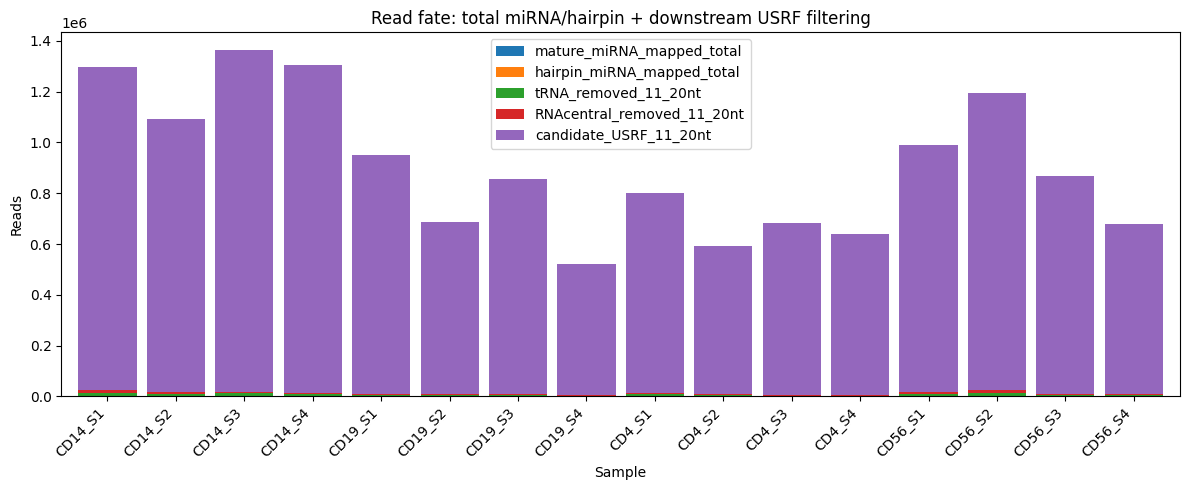

In [33]:
stack_cols_full = [
    "mature_miRNA_mapped_total",
    "hairpin_miRNA_mapped_total",
    "tRNA_removed_11_20nt",
    "RNAcentral_removed_11_20nt",
    "candidate_USRF_11_20nt",
]

ax = plot_full_usrf.set_index("sample")[stack_cols_full].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5),
    width=0.85
)

ax.set_ylabel("Reads")
ax.set_xlabel("Sample")
ax.set_title("Read fate: total miRNA/hairpin + downstream USRF filtering")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "read_fate_total_miRNA_hairpin_plus_USRF.png", dpi=300)
plt.show()

In [35]:
from pathlib import Path
import pandas as pd
import json
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
NFCORE = ROOT / "01.nfcore_smrnaseq"
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"
OUT = QC / "usrf_11_20nt_plots"
OUT.mkdir(parents=True, exist_ok=True)

mature_unmapped = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "mature_unmapped_read_counts.txt",
    sep=None,
    engine="python"
)

hairpin_unmapped = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "hairpin_unmapped_read_counts.txt",
    sep=None,
    engine="python"
)

print("mature_unmapped columns:")
print(mature_unmapped.columns.tolist())
display(mature_unmapped.head())

print("hairpin_unmapped columns:")
print(hairpin_unmapped.columns.tolist())
display(hairpin_unmapped.head())

mature_unmapped columns:
['CD14_S3', 'CD19_S3', 'CD56_S2', 'CD4_S4', 'CD4_S3', 'CD4_S1', 'CD14_S2', 'CD19_S1', 'CD56_S3', 'CD4_S2', 'CD14_S4', 'CD56_S1', 'CD56_S4', 'CD19_S4', 'CD19_S2', 'CD14_S1']


,CD14_S3,CD19_S3,CD56_S2,CD4_S4,CD4_S3,CD4_S1,CD14_S2,CD19_S1,CD56_S3,CD4_S2,CD14_S4,CD56_S1,CD56_S4,CD19_S4,CD19_S2,CD14_S1
*,33398554,28322560,28209310,27097673,28340205,25651042,34639415,28031331,25976721,26788393,35238363,28245059,27713503,24019234,26483412,32136797


hairpin_unmapped columns:
['CD14_S1', 'CD56_S1', 'CD56_S3', 'CD14_S3', 'CD56_S4', 'CD14_S2', 'CD19_S4', 'CD56_S2', 'CD19_S2', 'CD4_S3', 'CD14_S4', 'CD4_S4', 'CD4_S1', 'CD4_S2', 'CD19_S1', 'CD19_S3']


,CD14_S1,CD56_S1,CD56_S3,CD14_S3,CD56_S4,CD14_S2,CD19_S4,CD56_S2,CD19_S2,CD4_S3,CD14_S4,CD4_S4,CD4_S1,CD4_S2,CD19_S1,CD19_S3
*,11276318,17623326,14589098,11535091,17877836,13203188,19730678,14407695,19877333,19421246,17559159,19077579,17193253,17855934,19191518,18703418


In [36]:
mature_unmapped_df = (
    mature_unmapped
    .T
    .reset_index()
    .rename(columns={"index": "sample", mature_unmapped.index[0]: "after_mature_miRNA_unmapped"})
)

hairpin_unmapped_df = (
    hairpin_unmapped
    .T
    .reset_index()
    .rename(columns={"index": "sample", hairpin_unmapped.index[0]: "after_hairpin_miRNA_unmapped"})
)

display(mature_unmapped_df.head())
display(hairpin_unmapped_df.head())

,sample,after_mature_miRNA_unmapped
0,CD14_S3,33398554
1,CD19_S3,28322560
2,CD56_S2,28209310
3,CD4_S4,27097673
4,CD4_S3,28340205


,sample,after_hairpin_miRNA_unmapped
0,CD14_S1,11276318
1,CD56_S1,17623326
2,CD56_S3,14589098
3,CD14_S3,11535091
4,CD56_S4,17877836


In [38]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
NFCORE = ROOT / "01.nfcore_smrnaseq"
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"
OUT = QC / "full_filtering_plots"
OUT.mkdir(parents=True, exist_ok=True)

# 1) fastp counts
fastp_rows = []
for fp in sorted((NFCORE / "fastp" / "on_raw").glob("*.fastp.json")):
    sample = fp.name.replace(".fastp.json", "")
    with open(fp) as f:
        js = json.load(f)
    fastp_rows.append({
        "sample": sample,
        "raw_reads": js["summary"]["before_filtering"]["total_reads"],
        "passed_fastp": js["summary"]["after_filtering"]["total_reads"],
    })
fastp_df = pd.DataFrame(fastp_rows)

# 2) mature/hairpin unmapped counts
mature_unmapped = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "mature_unmapped_read_counts.txt",
    sep=None, engine="python"
)
hairpin_unmapped = pd.read_csv(
    NFCORE / "mirna_quant" / "edger_qc" / "hairpin_unmapped_read_counts.txt",
    sep=None, engine="python"
)

mature_unmapped_df = (
    mature_unmapped.T.reset_index()
    .rename(columns={"index": "sample", mature_unmapped.index[0]: "after_mature_miRNA_unmapped"})
)

hairpin_unmapped_df = (
    hairpin_unmapped.T.reset_index()
    .rename(columns={"index": "sample", hairpin_unmapped.index[0]: "after_hairpin_miRNA_unmapped"})
)

# 3) custom downstream counts
custom_long = pd.read_csv(QC / "filter_counts.tsv", sep="\t")

custom_wide = (
    custom_long
    .pivot(index="sample", columns="stage", values="reads")
    .reset_index()
    .rename(columns={
        "input": "mature_hairpin_unmapped",
        "candidate_remaining": "candidate_USRF_total"
    })
)

# 4) merge
attrition = (
    fastp_df
    .merge(mature_unmapped_df, on="sample", how="left")
    .merge(hairpin_unmapped_df, on="sample", how="left")
    .merge(custom_wide, on="sample", how="left")
)

# 5) calculate removed/read-fate buckets
attrition["fastp_removed"] = attrition["raw_reads"] - attrition["passed_fastp"]
attrition["mature_miRNA_removed"] = attrition["passed_fastp"] - attrition["after_mature_miRNA_unmapped"]
attrition["hairpin_miRNA_removed"] = attrition["after_mature_miRNA_unmapped"] - attrition["after_hairpin_miRNA_unmapped"]
attrition["tRNA_removed"] = attrition["tRNA_matched"]
attrition["RNAcentral_removed"] = attrition["RNAcentral_matched"]

attrition.to_csv(QC / "full_filtering_attrition_counts.tsv", sep="\t", index=False)

display(attrition.head())
print(attrition.columns.tolist())

,sample,raw_reads,passed_fastp,after_mature_miRNA_unmapped,after_hairpin_miRNA_unmapped,RNAcentral_matched,candidate_USRF_total,mature_hairpin_unmapped,not_tRNA,tRNA_matched,fastp_removed,mature_miRNA_removed,hairpin_miRNA_removed,tRNA_removed,RNAcentral_removed
0,CD14_S1,33666454,33606041,32136797,11276318,16404,11188428,11276318,11204832,71486,60413,1469244,20860479,71486,16404
1,CD14_S2,36356801,36279556,34639415,13203188,10453,13150124,13203188,13160577,42611,77245,1640141,21436227,42611,10453
2,CD14_S3,35451156,35365237,33398554,11535091,9585,11503049,11535091,11512634,22457,85919,1966683,21863463,22457,9585
3,CD14_S4,37654239,36882410,35238363,17559159,11170,17532591,17559159,17543761,15398,771829,1644047,17679204,15398,11170
4,CD19_S1,30739877,30612117,28031331,19191518,10108,19169765,19191518,19179873,11645,127760,2580786,8839813,11645,10108


['sample', 'raw_reads', 'passed_fastp', 'after_mature_miRNA_unmapped', 'after_hairpin_miRNA_unmapped', 'RNAcentral_matched', 'candidate_USRF_total', 'mature_hairpin_unmapped', 'not_tRNA', 'tRNA_matched', 'fastp_removed', 'mature_miRNA_removed', 'hairpin_miRNA_removed', 'tRNA_removed', 'RNAcentral_removed']


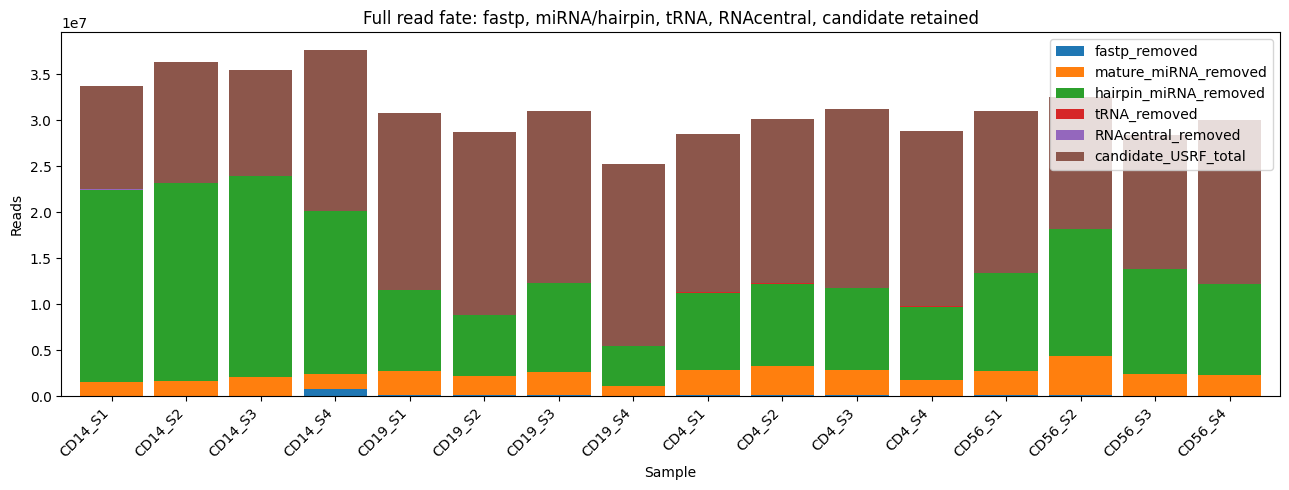

In [39]:
stack_cols = [
    "fastp_removed",
    "mature_miRNA_removed",
    "hairpin_miRNA_removed",
    "tRNA_removed",
    "RNAcentral_removed",
    "candidate_USRF_total",
]

ax = attrition.set_index("sample")[stack_cols].plot(
    kind="bar",
    stacked=True,
    figsize=(13, 5),
    width=0.85
)

ax.set_ylabel("Reads")
ax.set_xlabel("Sample")
ax.set_title("Full read fate: fastp, miRNA/hairpin, tRNA, RNAcentral, candidate retained")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUT / "full_read_fate_with_miRNA_hairpin.png", dpi=300)
plt.show()

In [40]:
from pathlib import Path
import gzip
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
NFCORE = ROOT / "01.nfcore_smrnaseq"
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"
OUT = QC / "usrf_10_20nt_plots"

OUT.mkdir(parents=True, exist_ok=True)

MIN_LEN = 10
MAX_LEN = 20

In [41]:
def count_fastq_len_window(fq, min_len=10, max_len=20):
    total = 0
    in_window = 0
    
    with gzip.open(fq, "rt") as f:
        for i, line in enumerate(f):
            if i % 4 == 1:
                L = len(line.strip())
                total += 1
                if min_len <= L <= max_len:
                    in_window += 1
                    
    return total, in_window


def count_bam_query_len_window(bam, min_len=10, max_len=20):
    """
    Counts aligned reads in BAM by query sequence length.
    Requires samtools in PATH.
    """
    total = 0
    in_window = 0
    
    cmd = ["samtools", "view", str(bam)]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True)
    
    for line in p.stdout:
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 10:
            continue
        seq = fields[9]
        if seq == "*":
            continue
        L = len(seq)
        total += 1
        if min_len <= L <= max_len:
            in_window += 1
    
    p.wait()
    if p.returncode != 0:
        raise RuntimeError(f"samtools view failed for {bam}")
        
    return total, in_window

In [44]:
import shutil
print(shutil.which("samtools"))

None


### USE

In [39]:
SAMTOOLS = "/samurlab1/Joshua/joshMiniforge3/envs/nextflow/bin/samtools"

from pathlib import Path
assert Path(SAMTOOLS).exists(), f"samtools not found at {SAMTOOLS}"

In [40]:
def count_bam_query_len_window(bam, min_len=10, max_len=20):
    import subprocess
    
    total = 0
    in_window = 0
    
    cmd = [SAMTOOLS, "view", str(bam)]
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    
    for line in p.stdout:
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 10:
            continue
        
        seq = fields[9]
        if seq == "*":
            continue
        
        L = len(seq)
        total += 1
        if min_len <= L <= max_len:
            in_window += 1
    
    stderr = p.stderr.read()
    p.wait()
    
    if p.returncode != 0:
        raise RuntimeError(f"samtools view failed for {bam}\n{stderr}")
    
    return total, in_window

In [43]:
NFCORE = Path("/samurlab1/Joshua/smallRNA_USRF/01.nfcore_smrnaseq")

mature_bam_dir = NFCORE / "mirna_quant" / "bam" / "mature"
hairpin_bam_dir = NFCORE / "mirna_quant" / "bam" / "hairpin"

print(mature_bam_dir.exists(), hairpin_bam_dir.exists())

True True


In [44]:
records = []

for bam in sorted(mature_bam_dir.glob("*_mature.bam")):
    print(bam.name)
    sample = bam.name.replace("_mature.bam", "")
    total, n_window = count_bam_query_len_window(bam, MIN_LEN, MAX_LEN)

    records.append({
        "sample": sample,
        "stage": "mature_miRNA_mapped",
        "total_reads": total,
        "reads_10_20nt": n_window
    })

for bam in sorted(hairpin_bam_dir.glob("*_mature_hairpin.bam")):
    print(bam.name)
    sample = bam.name.replace("_mature_hairpin.bam", "")
    total, n_window = count_bam_query_len_window(bam, MIN_LEN, MAX_LEN)

    records.append({
        "sample": sample,
        "stage": "hairpin_miRNA_mapped",
        "total_reads": total,
        "reads_10_20nt": n_window
    })

print("records:", len(records))

CD14_S1_mature.bam
CD14_S2_mature.bam
CD14_S3_mature.bam
CD14_S4_mature.bam
CD19_S1_mature.bam
CD19_S2_mature.bam
CD19_S3_mature.bam
CD19_S4_mature.bam
CD4_S1_mature.bam
CD4_S2_mature.bam
CD4_S3_mature.bam
CD4_S4_mature.bam
CD56_S1_mature.bam
CD56_S2_mature.bam
CD56_S3_mature.bam
CD56_S4_mature.bam
CD14_S1_mature_hairpin.bam
CD14_S2_mature_hairpin.bam
CD14_S3_mature_hairpin.bam
CD14_S4_mature_hairpin.bam
CD19_S1_mature_hairpin.bam
CD19_S2_mature_hairpin.bam
CD19_S3_mature_hairpin.bam
CD19_S4_mature_hairpin.bam
CD4_S1_mature_hairpin.bam
CD4_S2_mature_hairpin.bam
CD4_S3_mature_hairpin.bam
CD4_S4_mature_hairpin.bam
CD56_S1_mature_hairpin.bam
CD56_S2_mature_hairpin.bam
CD56_S3_mature_hairpin.bam
CD56_S4_mature_hairpin.bam
records: 32


In [42]:
print("NFCORE:", NFCORE)
print("mature dir:", mature_bam_dir)
print("exists:", mature_bam_dir.exists())
print("n bam:", len(list(mature_bam_dir.glob("*.bam"))))

print("hairpin dir:", hairpin_bam_dir)
print("exists:", hairpin_bam_dir.exists())
print("n bam:", len(list(hairpin_bam_dir.glob("*.bam"))))

NFCORE: /samurlab1/Joshua/smallRNA_USRF/results
mature dir: /samurlab1/Joshua/smallRNA_USRF/results/mirna_quant/bam/mature
exists: False
n bam: 0
hairpin dir: /samurlab1/Joshua/smallRNA_USRF/results/mirna_quant/bam/hairpin
exists: False
n bam: 0


In [45]:
import pandas as pd
from pathlib import Path

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
CUSTOM = ROOT / "03.shortRNA_filtering"
QC = CUSTOM / "qc"

bam_usrf = pd.DataFrame(records)

print(bam_usrf.shape)
display(bam_usrf.head())
print(bam_usrf.columns.tolist())

bam_usrf.to_csv(QC / "mirna_hairpin_bam_10_20nt_counts.tsv", sep="\t", index=False)

print("Saved:", QC / "mirna_hairpin_bam_10_20nt_counts.tsv")

(32, 4)


,sample,stage,total_reads,reads_10_20nt
0,CD14_S1,mature_miRNA_mapped,35571428,35571428
1,CD14_S2,mature_miRNA_mapped,38203648,38203648
2,CD14_S3,mature_miRNA_mapped,37449014,37449014
3,CD14_S4,mature_miRNA_mapped,38926256,38926256
4,CD19_S1,mature_miRNA_mapped,31717921,31717921


['sample', 'stage', 'total_reads', 'reads_10_20nt']
Saved: /samurlab1/Joshua/smallRNA_USRF/03.shortRNA_filtering/qc/mirna_hairpin_bam_10_20nt_counts.tsv


In [46]:
usrf = pd.read_csv(QC / "usrf_10_20nt_filter_counts.tsv", sep="\t")

read_col = "reads_10_20nt" if "reads_10_20nt" in usrf.columns else "reads_10_20nt"

downstream = usrf[["sample", "stage", read_col]].rename(columns={read_col: "reads_10_20nt"})
upstream = bam_usrf[["sample", "stage", "reads_10_20nt"]]

combined = pd.concat([upstream, downstream], ignore_index=True)
combined.to_csv(QC / "usrf_10_20nt_full_combined_counts.tsv", sep="\t", index=False)

wide = (
    combined
    .pivot_table(index="sample", columns="stage", values="reads_10_20nt", aggfunc="sum")
    .reset_index()
    .fillna(0)
)

wide.to_csv(QC / "usrf_10_20nt_full_combined_wide.tsv", sep="\t", index=False)

display(wide.head())

stage,sample,RNAcentral_matched,candidate_USRF,hairpin_miRNA_mapped,mature_miRNA_mapped,not_tRNA,tRNA_matched
0,CD14_S1,11414,1273082,11213845,35571428,1284496,14284
1,CD14_S2,5951,1078283,13328913,38203648,1084234,10009
2,CD14_S3,6365,1347276,12025764,37449014,1353641,11935
3,CD14_S4,6182,1292042,17952986,38926256,1298224,7894
4,CD19_S1,6466,940162,20397811,31717921,946628,4162


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
QC = ROOT / "03.shortRNA_filtering/qc"
OUT = QC / "artistic_figures"
OUT.mkdir(exist_ok=True, parents=True)

wide = pd.read_csv(QC / "usrf_10_20nt_full_combined_wide.tsv", sep="\t")

wide["cell_type"] = wide["sample"].str.replace(r"_S\d+$", "", regex=True)

wide["mature miRNA removed"] = wide.get("mature_miRNA_mapped", 0)
wide["hairpin miRNA removed"] = wide.get("hairpin_miRNA_mapped", 0)
wide["tRNA removed"] = wide.get("tRNA_matched", 0)
wide["RNAcentral removed"] = wide.get("RNAcentral_matched", 0)
wide["candidate USRF retained"] = wide.get("candidate_USRF", 0)

display(wide.head())

,sample,RNAcentral_matched,candidate_USRF,hairpin_miRNA_mapped,mature_miRNA_mapped,not_tRNA,tRNA_matched,cell_type,mature miRNA removed,hairpin miRNA removed,tRNA removed,RNAcentral removed,candidate USRF retained
0,CD14_S1,11414,1273082,2238532,3180847,1284496,14284,CD14,3180847,2238532,14284,11414,1273082
1,CD14_S2,5951,1078283,2154476,2893440,1084234,10009,CD14,2893440,2154476,10009,5951,1078283
2,CD14_S3,6365,1347276,2581872,3397893,1353641,11935,CD14,3397893,2581872,11935,6365,1347276
3,CD14_S4,6182,1292042,2233257,3033841,1298224,7894,CD14,3033841,2233257,7894,6182,1292042
4,CD19_S1,6466,940162,1980831,3278066,946628,4162,CD19,3278066,1980831,4162,6466,940162


In [49]:
print(wide.columns.tolist())

['sample', 'RNAcentral_matched', 'candidate_USRF', 'hairpin_miRNA_mapped', 'mature_miRNA_mapped', 'not_tRNA', 'tRNA_matched']


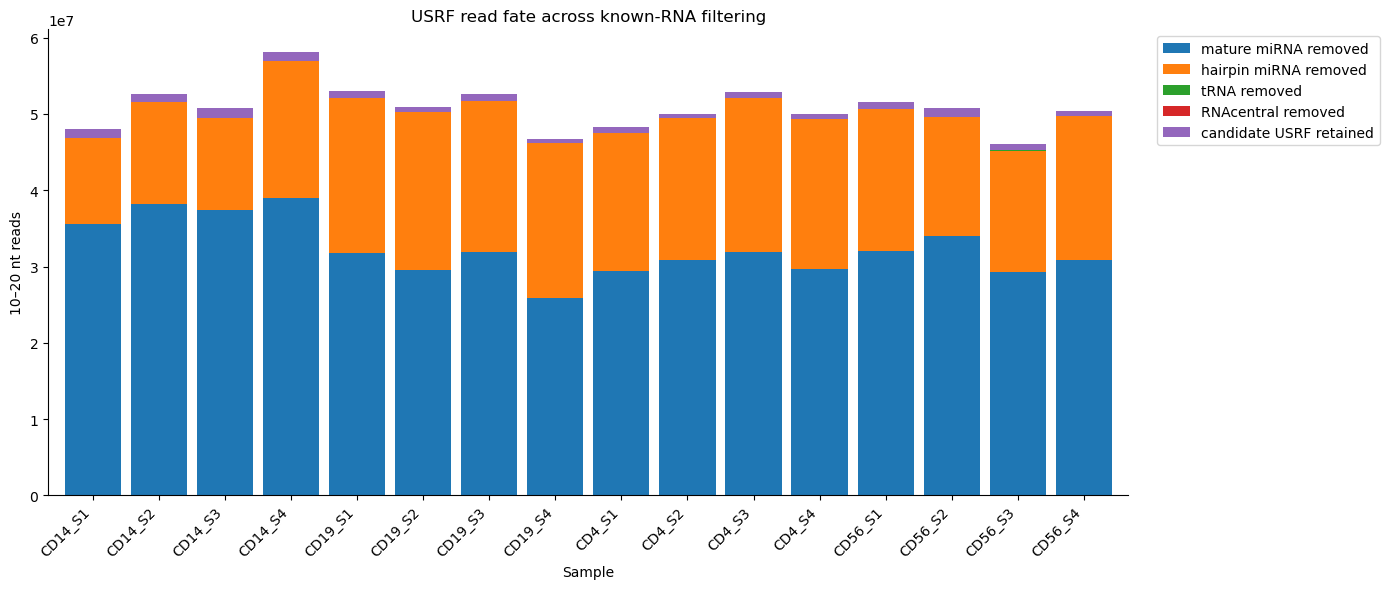

In [50]:
wide.columns.name = None

rename_map = {
    "mature_miRNA_mapped": "mature miRNA removed",
    "hairpin_miRNA_mapped": "hairpin miRNA removed",
    "tRNA_matched": "tRNA removed",
    "RNAcentral_matched": "RNAcentral removed",
    "candidate_USRF": "candidate USRF retained",
}

plot = (
    wide
    .rename(columns=rename_map)
    .set_index("sample")[
        [
            "mature miRNA removed",
            "hairpin miRNA removed",
            "tRNA removed",
            "RNAcentral removed",
            "candidate USRF retained",
        ]
    ]
)

ax = plot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    width=0.85
)

ax.set_ylabel("10–20 nt reads")
ax.set_xlabel("Sample")
ax.set_title("USRF read fate across known-RNA filtering")
ax.spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

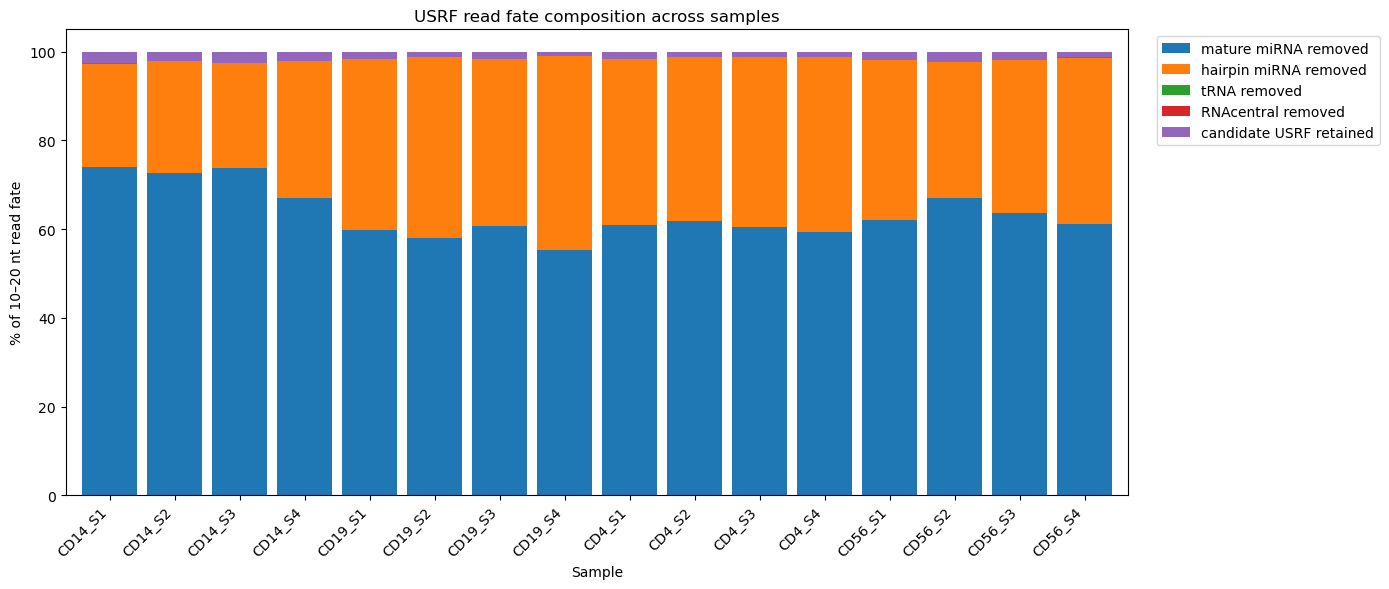

In [52]:
plot_pct = plot.div(plot.sum(axis=1), axis=0) * 100
plot_pct.plot(kind="bar", stacked=True, figsize=(14, 6), width=0.85)
plt.ylabel("% of 10–20 nt read fate")
plt.xlabel("Sample")
plt.title("USRF read fate composition across samples")
plt.xticks(rotation=45, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

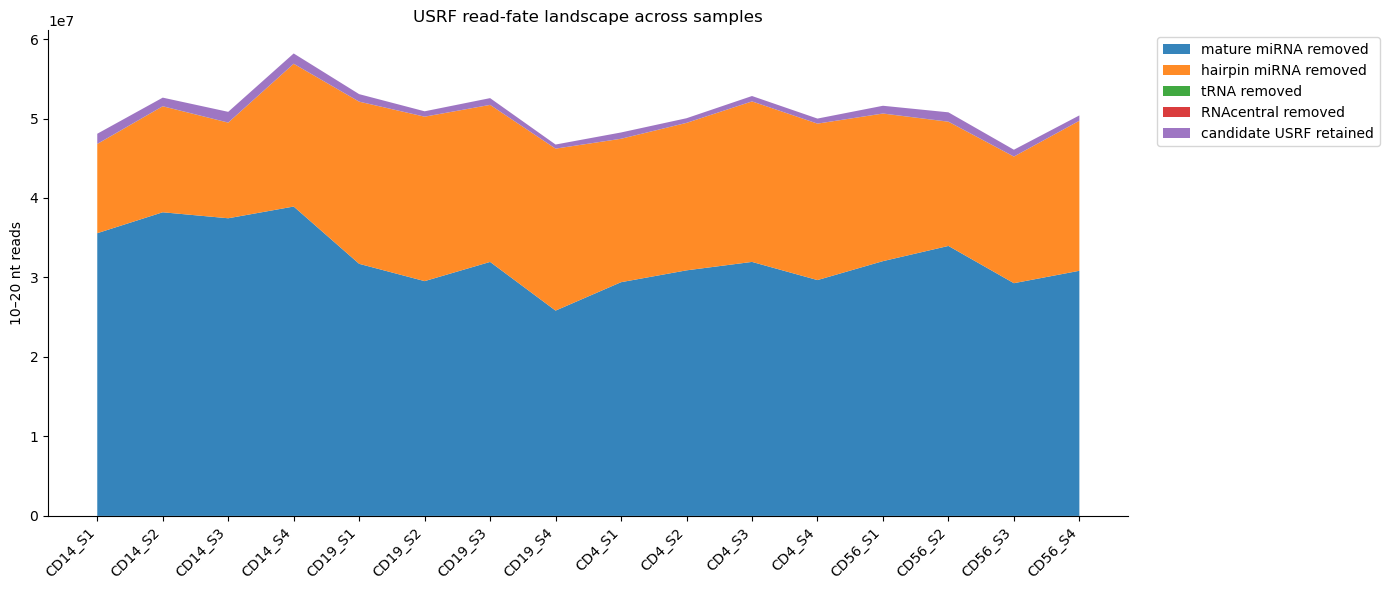

In [53]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.stackplot(
    range(len(plot)),
    plot.T.values,
    labels=plot.columns,
    alpha=0.9
)

ax.set_xticks(range(len(plot)))
ax.set_xticklabels(plot.index, rotation=45, ha="right")
ax.set_ylabel("10–20 nt reads")
ax.set_title("USRF read-fate landscape across samples")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "usrf_10_20nt_streamgraph_read_fate.png", dpi=300)
plt.show()

In [55]:
wide = wide.copy()
wide.columns.name = None

wide["cell_type"] = wide["sample"].str.replace(r"_S\d+$", "", regex=True)
wide["candidate USRF retained"] = wide["candidate_USRF"]

cell_summary = (
    wide.groupby("cell_type")["candidate USRF retained"]
    .agg(["mean", "std", "sum"])
    .reset_index()
)

display(cell_summary)

,cell_type,mean,std,sum
0,CD14,1247670.75,117229.056595,4990683
1,CD19,743915.75,188531.908959,2975663
2,CD4,669737.75,87761.660974,2678951
3,CD56,918020.25,210112.831289,3672081


,cell_type,mean,std,sum
0,CD14,1247670.75,117229.056595,4990683
1,CD19,743915.75,188531.908959,2975663
2,CD4,669737.75,87761.660974,2678951
3,CD56,918020.25,210112.831289,3672081


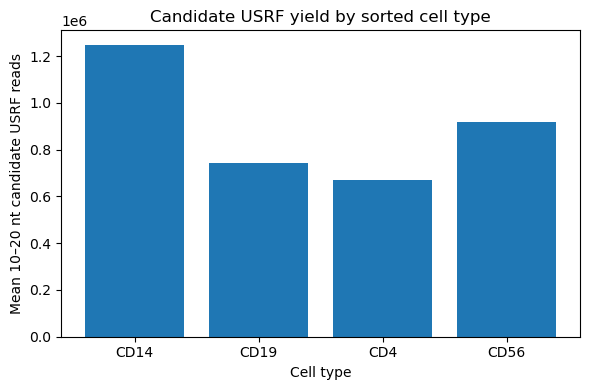

In [56]:
cell_summary = wide.groupby("cell_type")["candidate USRF retained"].agg(["mean","std","sum"]).reset_index()
display(cell_summary)

plt.figure(figsize=(6,4))
plt.bar(cell_summary["cell_type"], cell_summary["mean"])
plt.ylabel("Mean 10–20 nt candidate USRF reads")
plt.xlabel("Cell type")
plt.title("Candidate USRF yield by sorted cell type")
plt.tight_layout()
plt.savefig(OUT / "candidate_USRF_yield_by_cell_type.png", dpi=300)
plt.show()

In [59]:
wide = wide.copy()
wide.columns.name = None

wide["cell_type"] = wide["sample"].str.replace(r"_S\d+$", "", regex=True)

wide["mature miRNA removed"] = wide["mature_miRNA_mapped"]
wide["hairpin miRNA removed"] = wide["hairpin_miRNA_mapped"]
wide["tRNA removed"] = wide["tRNA_matched"]
wide["RNAcentral removed"] = wide["RNAcentral_matched"]
wide["candidate USRF retained"] = wide["candidate_USRF"]

cols = [
    "mature miRNA removed",
    "hairpin miRNA removed",
    "tRNA removed",
    "RNAcentral removed",
    "candidate USRF retained",
]

wide["total_10_20nt_screened"] = wide[cols].sum(axis=1)
wide["pct_candidate_USRF"] = (
    wide["candidate USRF retained"] / wide["total_10_20nt_screened"] * 100
)

display(wide[["sample", "cell_type", "total_10_20nt_screened", "pct_candidate_USRF"]].head())

,sample,cell_type,total_10_20nt_screened,pct_candidate_USRF
0,CD14_S1,CD14,48084053,2.647618
1,CD14_S2,CD14,52626804,2.048924
2,CD14_S3,CD14,50840354,2.650013
3,CD14_S4,CD14,58185360,2.220562
4,CD19_S1,CD19,53066522,1.771667


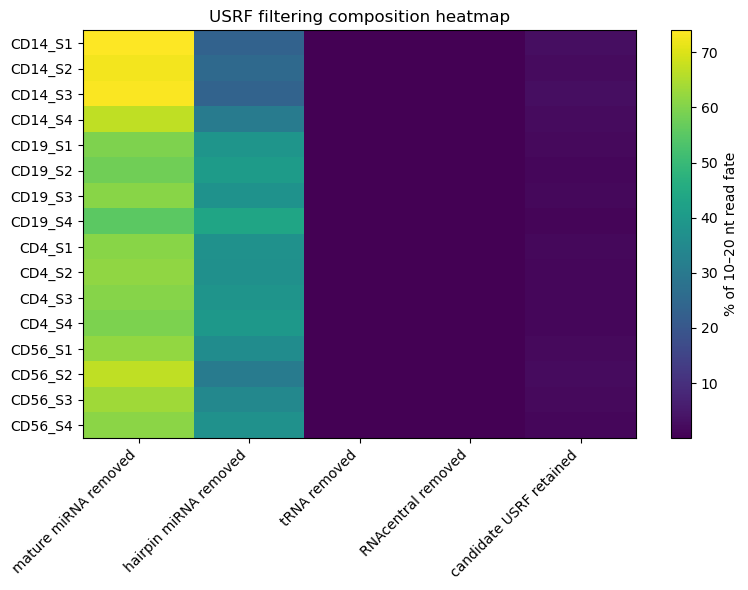

In [60]:
heat = wide.set_index("sample")[cols]
heat_pct = heat.div(heat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(heat_pct.values, aspect="auto")

ax.set_xticks(range(len(heat_pct.columns)))
ax.set_xticklabels(heat_pct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heat_pct.index)))
ax.set_yticklabels(heat_pct.index)

plt.colorbar(im, ax=ax, label="% of 10–20 nt read fate")
ax.set_title("USRF filtering composition heatmap")
plt.tight_layout()
plt.savefig(OUT / "usrf_filtering_composition_heatmap.png", dpi=300)
plt.show()

In [61]:
summary = wide[[
    "sample", "cell_type",
    "mature miRNA removed",
    "hairpin miRNA removed",
    "tRNA removed",
    "RNAcentral removed",
    "candidate USRF retained",
    "pct_candidate_USRF"
]]

summary.to_csv(QC / "usrf_10_20nt_boss_summary.tsv", sep="\t", index=False)
display(summary)

,sample,cell_type,mature miRNA removed,hairpin miRNA removed,tRNA removed,RNAcentral removed,candidate USRF retained,pct_candidate_USRF
0,CD14_S1,CD14,35571428,11213845,14284,11414,1273082,2.647618
1,CD14_S2,CD14,38203648,13328913,10009,5951,1078283,2.048924
2,CD14_S3,CD14,37449014,12025764,11935,6365,1347276,2.650013
3,CD14_S4,CD14,38926256,17952986,7894,6182,1292042,2.220562
4,CD19_S1,CD19,31717921,20397811,4162,6466,940162,1.771667
5,CD19_S2,CD19,29541558,20682719,4234,6891,673989,1.323899
6,CD19_S3,CD19,31956934,19752106,3716,5595,846967,1.611266
7,CD19_S4,CD19,25832450,20373338,2078,4807,514545,1.101168
8,CD4_S1,CD4,29407005,18037010,8278,4834,787843,1.633005
9,CD4_S2,CD4,30897607,18545724,6963,3872,581618,1.162404


In [62]:
import gzip
from pathlib import Path

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
CUSTOM = ROOT / "03.shortRNA_filtering/03.filtered"

def get_unique_sequences(fq):
    seqs = set()
    with gzip.open(fq, "rt") as f:
        for i, line in enumerate(f):
            if i % 4 == 1:
                seqs.add(line.strip())
    return seqs

sample_seqs = {}

for sample_dir in sorted(CUSTOM.glob("*")):
    if not sample_dir.is_dir():
        continue
    
    sample = sample_dir.name
    fq = sample_dir / f"{sample}.candidate_shortRNA.fastq.gz"
    
    if fq.exists():
        print(sample)
        sample_seqs[sample] = get_unique_sequences(fq)

len(sample_seqs)

CD14_S1
CD14_S2
CD14_S3
CD14_S4
CD19_S1
CD19_S2
CD19_S3
CD19_S4
CD4_S1
CD4_S2
CD4_S3
CD4_S4
CD56_S1
CD56_S2
CD56_S3
CD56_S4


16

In [63]:
from pathlib import Path
import pickle
import pandas as pd

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
QC = ROOT / "03.shortRNA_filtering/qc"
CHECKPOINTS = QC / "checkpoints"
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

In [65]:
from pathlib import Path
from collections import defaultdict
import pickle
import pandas as pd

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
QC = ROOT / "03.shortRNA_filtering/qc"
CHECKPOINTS = QC / "checkpoints"
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

# reload sample_seqs if needed
with open(CHECKPOINTS / "sample_candidate_USRF_sequence_sets.pkl", "rb") as f:
    sample_seqs = pickle.load(f)

celltype_replicate_sets = defaultdict(list)
for sample, seqs in sample_seqs.items():
    ct = sample.split("_S")[0]
    celltype_replicate_sets[ct].append(seqs)

celltype_union = {
    ct: set().union(*sets)
    for ct, sets in celltype_replicate_sets.items()
}

celltype_shared = {
    ct: set.intersection(*sets)
    for ct, sets in celltype_replicate_sets.items()
}

shared_all = set.intersection(*celltype_union.values())

cts = sorted(celltype_union)

overlap = pd.DataFrame(index=cts, columns=cts, dtype=int)
jaccard = pd.DataFrame(index=cts, columns=cts, dtype=float)

for a in cts:
    for b in cts:
        inter = len(celltype_union[a] & celltype_union[b])
        union = len(celltype_union[a] | celltype_union[b])
        overlap.loc[a, b] = inter
        jaccard.loc[a, b] = inter / union if union else 0

# Save missing checkpoints
with open(CHECKPOINTS / "celltype_candidate_USRF_union_sets.pkl", "wb") as f:
    pickle.dump(celltype_union, f)

with open(CHECKPOINTS / "celltype_shared_USRF_sets.pkl", "wb") as f:
    pickle.dump(celltype_shared, f)

with open(CHECKPOINTS / "USRF_shared_across_all_celltypes.pkl", "wb") as f:
    pickle.dump(shared_all, f)

overlap.to_csv(QC / "USRF_celltype_pairwise_overlap.tsv", sep="\t")
jaccard.to_csv(QC / "USRF_celltype_pairwise_jaccard.tsv", sep="\t")

# Save readable sequence lists
for ct, seqs in celltype_shared.items():
    pd.Series(sorted(seqs), name="sequence").to_csv(
        QC / f"{ct}_shared_USRF_sequences.tsv",
        sep="\t",
        index=False
    )

pd.Series(sorted(shared_all), name="sequence").to_csv(
    QC / "USRF_shared_across_all_celltypes.tsv",
    sep="\t",
    index=False
)

print("Saved shared/overlap/Jaccard outputs.")
print({ct: len(v) for ct, v in celltype_shared.items()})
print("Shared across all cell types:", len(shared_all))

The history saving thread hit an unexpected error (OperationalError('unable to open database file')).History will not be written to the database.
Saved shared/overlap/Jaccard outputs.
{'CD14': 94130, 'CD19': 122459, 'CD4': 106570, 'CD56': 111534}
Shared across all cell types: 296097


In [64]:
from pathlib import Path
from collections import defaultdict
import pickle
import pandas as pd

ROOT = Path("/samurlab1/Joshua/smallRNA_USRF")
QC = ROOT / "03.shortRNA_filtering/qc"
CHECKPOINTS = QC / "checkpoints"

with open(CHECKPOINTS / "sample_candidate_USRF_sequence_sets.pkl", "rb") as f:
    sample_seqs = pickle.load(f)

celltype_sets = defaultdict(list)
for sample, seqs in sample_seqs.items():
    ct = sample.split("_S")[0]
    celltype_sets[ct].append(seqs)

celltype_shared = {
    ct: set.intersection(*sets)
    for ct, sets in celltype_sets.items()
}

celltype_union = {
    ct: set.union(*sets)
    for ct, sets in celltype_sets.items()
}

shared_all_celltypes = set.intersection(*celltype_union.values())

# save conserved sequence lists
for ct, seqs in celltype_shared.items():
    pd.Series(sorted(seqs), name="sequence").to_csv(
        QC / f"{ct}_replicate_conserved_USRF_sequences.tsv",
        sep="\t",
        index=False
    )

pd.Series(sorted(shared_all_celltypes), name="sequence").to_csv(
    QC / "all_celltypes_conserved_USRF_sequences.tsv",
    sep="\t",
    index=False
)

# save summary table
conserved_summary = pd.DataFrame({
    "cell_type": list(celltype_shared.keys()),
    "n_replicate_conserved_sequences": [len(v) for v in celltype_shared.values()],
    "n_union_sequences": [len(celltype_union[ct]) for ct in celltype_shared.keys()]
})

conserved_summary.to_csv(QC / "USRF_conserved_sequence_summary.tsv", sep="\t", index=False)

print("Saved conserved sequence analysis tables.")
display(conserved_summary)
print("Conserved across all cell types:", len(shared_all_celltypes))

Saved conserved sequence analysis tables.


,cell_type,n_replicate_conserved_sequences,n_union_sequences
0,CD14,94130,5300129
1,CD19,122459,3796826
2,CD4,106570,3871168
3,CD56,111534,4294847


Conserved across all cell types: 296097
